### 1. Setup


In [131]:
# install required libraries - can also be executed in the terminal in .venv
# %pip install -r requirements.txt

In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupShuffleSplit ,StratifiedGroupKFold, cross_validate, RandomizedSearchCV 
from scipy.stats import randint , uniform
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression 
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    classification_report
)

In [133]:
pd.set_option("display.max_columns",None)
pd.set_option("display.float_format", lambda x : f"{x:.3f}")
sns.set_theme(style="darkgrid")

RANDOM_STATE=44
CSV_PATH=r"A:\GitHub\MediBuddy-ML-heart-disease-predictor\dataset\heart.csv"
TARGET_COL="target"

### 2.Load CSV

In [134]:
df=pd.read_csv(CSV_PATH)
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.000,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.100,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.600,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.000,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.900,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.000,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.800,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.000,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.000,2,0,2,1


In [135]:
print(df.shape)
print(df.columns)

(1025, 14)
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')


In [136]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [137]:
nunique=[]
for col in df.columns:
   dic={"col":col,"n":df[col].nunique()}
   nunique.append(dic)
nuniq=pd.DataFrame(nunique)
display(nuniq.sort_values(by='n').style.hide(axis='index'))

col,n
sex,2
fbs,2
target,2
exang,2
restecg,3
slope,3
thal,4
cp,4
ca,5
oldpeak,40


| Column Name | Short Description | Feature Type |
|------------|-------------------|--------------|
| age | Age of the patient (in years) | Numerical |
| sex | Sex of the patient (1 = male, 0 = female) | Categorical |
| cp | Chest pain type (0–3 representing different chest pain categories) | Categorical |
| trestbps | Resting blood pressure (in mm Hg) | Numerical |
| chol | Serum cholesterol level (in mg/dl) | Numerical |
| fbs | Fasting blood sugar > 120 mg/dl (1 = true, 0 = false) | Categorical |
| restecg | Resting electrocardiographic results (0–2) | Categorical |
| thalach | Maximum heart rate achieved | Numerical |
| exang | Exercise-induced angina (1 = yes, 0 = no) | Categorical |
| oldpeak | ST depression induced by exercise relative to rest | Numerical |
| slope | Slope of the peak exercise ST segment (0–2) | Categorical |
| ca | Number of major vessels colored by fluoroscopy (0–4) | Numerical |
| thal | Thalassemia status (0 = normal, 1 = fixed defect, 2 = reversible defect, 3 = unknown) | Categorical |
| target | Presence of heart disease (1 = disease, 0 = no disease) | Categorical |

In [138]:
cat_cols=[]
num_cols=[]

for col in df.columns:
    if df[col].nunique() < 5:
      cat_cols.append(col)
    else :
      num_cols.append(col)

print(f"num_cols: {num_cols}")
print(f"cat_cols: {cat_cols}")

num_cols: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
cat_cols: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'target']


In [139]:
# encoded missing values
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,1025.000,54.434,9.072,29.000,48.000,56.000,61.000,77.000
trestbps,1025.000,131.612,17.517,94.000,120.000,130.000,140.000,200.000
chol,1025.000,246.000,51.593,126.000,211.000,240.000,275.000,564.000
thalach,1025.000,149.114,23.006,71.000,132.000,152.000,166.000,202.000
oldpeak,1025.000,1.072,1.175,0.000,0.000,0.800,1.800,6.200
ca,1025.000,0.754,1.031,0.000,0.000,0.000,1.000,4.000


In [140]:
df[cat_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
sex,1025.000,0.696,0.460,0.000,0.000,1.000,1.000,1.000
cp,1025.000,0.942,1.030,0.000,0.000,1.000,2.000,3.000
fbs,1025.000,0.149,0.357,0.000,0.000,0.000,0.000,1.000
restecg,1025.000,0.530,0.528,0.000,0.000,1.000,1.000,2.000
exang,1025.000,0.337,0.473,0.000,0.000,0.000,1.000,1.000
slope,1025.000,1.385,0.618,0.000,1.000,1.000,2.000,2.000
thal,1025.000,2.324,0.621,0.000,2.000,2.000,3.000,3.000
target,1025.000,0.513,0.500,0.000,0.000,1.000,1.000,1.000


In [141]:
df.duplicated().sum()

np.int64(723)

>Although the dataset contains a large number of duplicate rows, these likely represent multiple real-world patients with identical clinical measurements. Dropping these rows would drastically reduce the dataset size and distort the natural frequency of observations in the data.

>We therefore retain duplicate rows, but take special care during validation. To ensure a fair evaluation, we use group-based splitting (Group K-Fold) so that identical data points are never shared between training and validation folds.

>While tree-based models are robust to duplicate observations during training, preventing duplicate leakage across folds is essential to obtain reliable and unbiased performance estimates.

In [142]:
df[TARGET_COL].value_counts(normalize=True)

target
1   0.513
0   0.487
Name: proportion, dtype: float64

### Data Visuavilisation

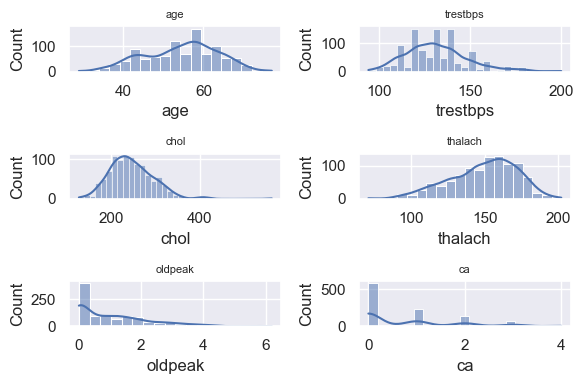

In [143]:
# histogram plot - distribution - for numerical features
fig, axes = plt.subplots(3, 2, figsize=(6, 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

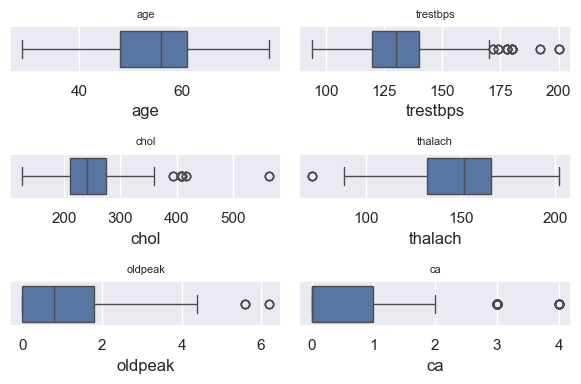

In [144]:
# outliers analysis - boxplot
fig, axes = plt.subplots(3, 2, figsize=(6, 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

>Not much outliers. We can leave it as is

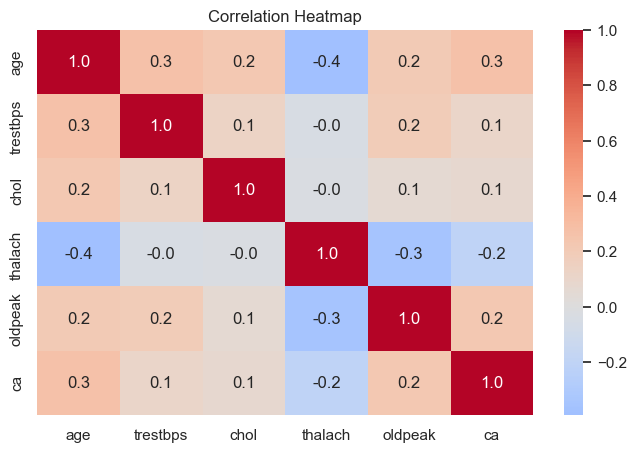

In [145]:
# identify presence of highly correlated columns & feature relationships
plt.figure(figsize=(8, 5))
sns.heatmap(
    df[num_cols].corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".1f",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

### Data Preprocessing

In [146]:
X=df.drop(columns=TARGET_COL)
y=df[TARGET_COL]

# Create a signature for each feature row - to prevent duplicates flow to test set
row_signature=pd.util.hash_pandas_object(X,index=False)

In [147]:
row_signature

0         227725699829427419
1          50836151723211046
2       10894799888851965450
3        7685467519808865474
4        7567925198380305935
                ...         
1020     3225181974515146756
1021    18154997444670469537
1022     5193280767241158862
1023     6006013119690573124
1024    18087355452203249959
Length: 1025, dtype: uint64

In [148]:
print(row_signature.shape)   # (n_rows,)
print(row_signature.nunique()) # how many unique row fingerprints
row_signature.value_counts()   # which signatures repeat (duplicates)

(1025,)
302


14965783813693067797    8
227725699829427419      4
50836151723211046       4
10894799888851965450    4
7685467519808865474     4
                       ..
1582527887802242469     3
525863784005463441      3
12753583602035017411    3
10693865592218026209    3
18087355452203249959    3
Name: count, Length: 302, dtype: int64

In [159]:
gss=GroupShuffleSplit(
    n_splits=1,
    test_size=0.15,
    random_state=RANDOM_STATE
    )

train_idx , test_idx = next(gss.split(X, y, groups=row_signature))

X_train , y_train =X.iloc[train_idx] ,y.iloc[train_idx]
X_test , y_test = X.iloc[test_idx] , y.iloc[test_idx]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\ndistribution based on target")
print("y_train",y_train.value_counts(normalize=True))
print("y_test",y_test.value_counts(normalize=True))

Train shape: (868, 13)
Test shape: (157, 13)

distribution based on target
y_train target
1   0.521
0   0.479
Name: proportion, dtype: float64
y_test target
0   0.529
1   0.471
Name: proportion, dtype: float64


### 5.Baseline Model    

In [152]:
basePipe=Pipeline(steps=[
    ("scaler",StandardScaler()),
    ("model",LogisticRegression())
])

In [153]:
basePipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

In [154]:
# reusable evaluation function
def evaluate_classifier(model, X_train, y_train, X_test, y_test, model_name):
    # predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # accuracy
    train_acc = accuracy_score(y_train, y_train_pred) * 100
    test_acc = accuracy_score(y_test, y_test_pred) * 100

    # results
    print(f"{model_name} - Train Accuracy: {train_acc:.2f}%")
    print(f"{model_name} - Test Accuracy: {test_acc:.2f}%\n")

    print("-"*40)

    print("Train Classification Report")
    print(classification_report(y_train, y_train_pred))

    print("-"*40)

    print("Test Classification Report")
    print(classification_report(y_test, y_test_pred))

In [155]:
evaluate_classifier(
    basePipe,
    X_train,
    y_train,
    X_test,
    y_test,
    model_name="Logistic Regression - Base Model"
)

Logistic Regression - Base Model - Train Accuracy: 85.14%
Logistic Regression - Base Model - Test Accuracy: 85.35%

----------------------------------------
Train Classification Report
              precision    recall  f1-score   support

           0       0.88      0.79      0.84       416
           1       0.83      0.90      0.86       452

    accuracy                           0.85       868
   macro avg       0.86      0.85      0.85       868
weighted avg       0.85      0.85      0.85       868

----------------------------------------
Test Classification Report
              precision    recall  f1-score   support

           0       0.94      0.77      0.85        83
           1       0.79      0.95      0.86        74

    accuracy                           0.85       157
   macro avg       0.86      0.86      0.85       157
weighted avg       0.87      0.85      0.85       157



### 6.Model Selection

In [156]:
models={
    'LogisticRegression' : LogisticRegression(random_state=RANDOM_STATE),
    'SVC':SVC(random_state=RANDOM_STATE),
    'RandomForestClassifier':RandomForestClassifier(random_state=RANDOM_STATE),
    'XGBClassifier':XGBClassifier()
}


In [ ]:

groups=pd.util.hash_pandas_object(X_train,index=False)

cv=StratifiedGroupKFold(n_splits=4,shuffle=True,random_state=RANDOM_STATE)

In [165]:
scores= cross_validate(
    estimator=basePipe,
    X=X_train,
    y=y_train,
    cv=cv,
    groups=groups,
    scoring=['f1','recall'],
    return_train_score=True
)


In [167]:
scores

{'fit_time': array([0.01382565, 0.01084328, 0.01352453, 0.0062952 ]),
 'score_time': array([0.0160768 , 0.00627923, 0.01028585, 0.00551891]),
 'test_f1': array([0.79047619, 0.83739837, 0.84081633, 0.78947368]),
 'train_f1': array([0.87428571, 0.8547486 , 0.87283237, 0.87553648]),
 'test_recall': array([0.72173913, 0.91964286, 0.91964286, 0.79646018]),
 'train_recall': array([0.90801187, 0.9       , 0.88823529, 0.90265487])}

In [168]:
model_performance=[]
for name,model in models.items():
    
    pipe=Pipeline(steps=[
        ("scaler",StandardScaler()),
        ("model",model)
    ])
    scores= cross_validate(
        estimator=pipe,
        X=X_train,
        y=y_train,
        groups=groups,
        cv=cv,
        scoring=['f1','recall'],
        return_train_score=True
    )

    dictionary={
        'model':name,
        'cv_recall':scores['test_recall'].mean(),
        'cv_f1':scores['test_f1'].mean()
        }
    model_performance.append(dictionary)

    

In [170]:
display(pd.DataFrame(model_performance))

,model,cv_recall,cv_f1
0,LogisticRegression,0.839,0.815
1,SVC,0.776,0.778
2,RandomForestClassifier,0.841,0.804
3,XGBClassifier,0.816,0.799


### 7.Hyper-Parameter Tuning

In [172]:
help(RandomForestClassifier())

Help on RandomForestClassifier in module sklearn.ensemble._forest object:

class RandomForestClassifier(ForestClassifier)
 |  RandomForestClassifier(
 |      n_estimators=100,
 |      *,
 |      criterion='gini',
 |      max_depth=None,
 |      min_samples_split=2,
 |      min_samples_leaf=1,
 |      min_weight_fraction_leaf=0.0,
 |      max_features='sqrt',
 |      max_leaf_nodes=None,
 |      min_impurity_decrease=0.0,
 |      bootstrap=True,
 |      oob_score=False,
 |      n_jobs=None,
 |      random_state=None,
 |      verbose=0,
 |      warm_start=False,
 |      class_weight=None,
 |      ccp_alpha=0.0,
 |      max_samples=None,
 |      monotonic_cst=None
 |  )
 |
 |  A random forest classifier.
 |
 |  A random forest is a meta estimator that fits a number of decision tree
 |  classifiers on various sub-samples of the dataset and uses averaging to
 |  improve the predictive accuracy and control over-fitting.
 |  Trees in the forest use the best split strategy, i.e. equivalent to 

In [181]:
rfc_pipe=Pipeline(steps=[
    ("scaler",StandardScaler()),
    ("model",RandomForestClassifier(random_state=RANDOM_STATE , n_jobs=-1))
])
params={
    "model__n_estimators":randint(70,1400),
    "model__max_depth":randint(3,20),
    "model__min_samples_split":randint(2,30),
    "model__min_samples_leaf":randint(1,20),
    "model__max_features":[0.25 , 0.35 ,0.5 ,"sqrt"],
    "model__bootstrap":[True],
    "model__max_samples":uniform(0.30,0.65),
    "model__ccp_alpha": uniform(0.0, 0.02)
}
scoring={
    "recall":"recall",
    "f1_macro":"f1_macro"
}
groups=pd.util.hash_pandas_object(X_train,index=False)
cv=StratifiedGroupKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)

In [239]:
random_search=RandomizedSearchCV(
    estimator=rfc_pipe,
    param_distributions=params,
    n_iter=1000,
    scoring=scoring,
    refit='recall',
    n_jobs=6,
    cv=cv,
    random_state=RANDOM_STATE,
    return_train_score=True
)

In [240]:
random_search.fit(X_train,y_train,groups=groups)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=44))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__bootstrap': [True], 'model__ccp_alpha': <scipy.stats....00233A846C8C0>, 'model__max_depth': <scipy.stats....00233A8459C70>, 'model__max_features': [0.25, 0.35, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",1000
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'f1_macro': 'f1_macro', 'recall': 'recall'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",6
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.

In [250]:
print(f"Best recall Score:{random_search.best_score_:.2%}")

Best recall Score:89.79%


In [259]:
print(f"Best Parameters:\n{random_search.best_params_}")

Best Parameters:
{'model__bootstrap': True, 'model__ccp_alpha': np.float64(7.2755034093985316e-06), 'model__max_depth': 9, 'model__max_features': 0.25, 'model__max_samples': np.float64(0.7437001697100011), 'model__min_samples_leaf': 2, 'model__min_samples_split': 20, 'model__n_estimators': 824}


In [251]:

cols = [
    "rank_test_recall",
    "mean_test_recall",
    "mean_test_f1_macro",
    "params"
]

cv_results_df = pd.DataFrame(random_search.cv_results_)[cols]
cv_results_df = cv_results_df.sort_values("rank_test_recall")
cv_results_df.head()

,rank_test_recall,mean_test_recall,mean_test_f1_macro,params
21,1,0.898,0.826,"{'model__bootstrap': True, 'model__ccp_alpha':..."
937,1,0.898,0.821,"{'model__bootstrap': True, 'model__ccp_alpha':..."
768,1,0.898,0.826,"{'model__bootstrap': True, 'model__ccp_alpha':..."
805,1,0.898,0.831,"{'model__bootstrap': True, 'model__ccp_alpha':..."
124,1,0.898,0.834,"{'model__bootstrap': True, 'model__ccp_alpha':..."


In [252]:
print("Best Parameters:")
pd.DataFrame([cv_results_df.iloc[0]["params"]]).T

Best Parameters:


,0
model__bootstrap,True
model__ccp_alpha,0.000
model__max_depth,9
model__max_features,0.250
model__max_samples,0.744
model__min_samples_leaf,2
model__min_samples_split,20
model__n_estimators,824


In [253]:
evaluate_classifier(
    random_search.best_estimator_,
    X_train,
    y_train,
    X_test,
    y_test,
    model_name="Random Forest - Best Model"
)

Random Forest - Best Model - Train Accuracy: 98.50%
Random Forest - Best Model - Test Accuracy: 87.90%

----------------------------------------
Train Classification Report
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       416
           1       0.99      0.98      0.99       452

    accuracy                           0.99       868
   macro avg       0.98      0.99      0.99       868
weighted avg       0.99      0.99      0.99       868

----------------------------------------
Test Classification Report
              precision    recall  f1-score   support

           0       0.91      0.86      0.88        83
           1       0.85      0.91      0.88        74

    accuracy                           0.88       157
   macro avg       0.88      0.88      0.88       157
weighted avg       0.88      0.88      0.88       157



### 8.Build a Predictive function

In [254]:
def predict_heart_disease(input_features):
    input_df=pd.DataFrame([input_features],columns=X_train.columns)
    prediction=random_search.best_estimator_.predict(input_df)[0]
    probability=random_search.best_estimator_.predict_proba(input_df)[0][1]

    # output
    print(f"Predicted class: {prediction}")
    print(f"Heart disease risk probability: {probability:.2%}")

    if prediction == 1:
        print("Diagnosis: High risk of heart disease 🔴")
    else:
        print("Diagnosis: Low risk of heart disease 🟢")

    return prediction, probability

In [255]:
X_test.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
2,70,1,0,145,174,0,1,125,1,2.600,0,0,3
14,52,1,0,128,204,1,1,156,1,1.000,1,0,0
23,63,0,2,135,252,0,0,172,0,0.000,2,0,2
29,55,0,0,180,327,0,2,117,1,3.400,1,0,2
33,70,1,2,160,269,0,1,112,1,2.900,1,1,3


In [256]:
y_test.head()

2     0
14    0
23    1
29    0
33    0
Name: target, dtype: int64

In [257]:
predict_heart_disease(X_test.iloc[14].to_list())

Predicted class: 1
Heart disease risk probability: 99.13%
Diagnosis: High risk of heart disease 🔴


(np.int64(1), np.float64(0.9913151795320261))

In [258]:
predict_heart_disease(X_test.iloc[23].to_list())

Predicted class: 0
Heart disease risk probability: 9.72%
Diagnosis: Low risk of heart disease 🟢


(np.int64(0), np.float64(0.09715177325847238))